In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binned_statistic_2d

## Importar tablas

In [14]:
members = pd.read_csv('../data/processed/members.csv')

## Comparación de diagramas Color-Color de miembros con masa y sin masa

Se separan los miembros que tienen masa de los que no tiene masa.

In [15]:
members_masses = members.dropna(subset=['Mass50']).copy()
members_no_masses = members[members['Mass50'].isna()].copy()

### Diagrama

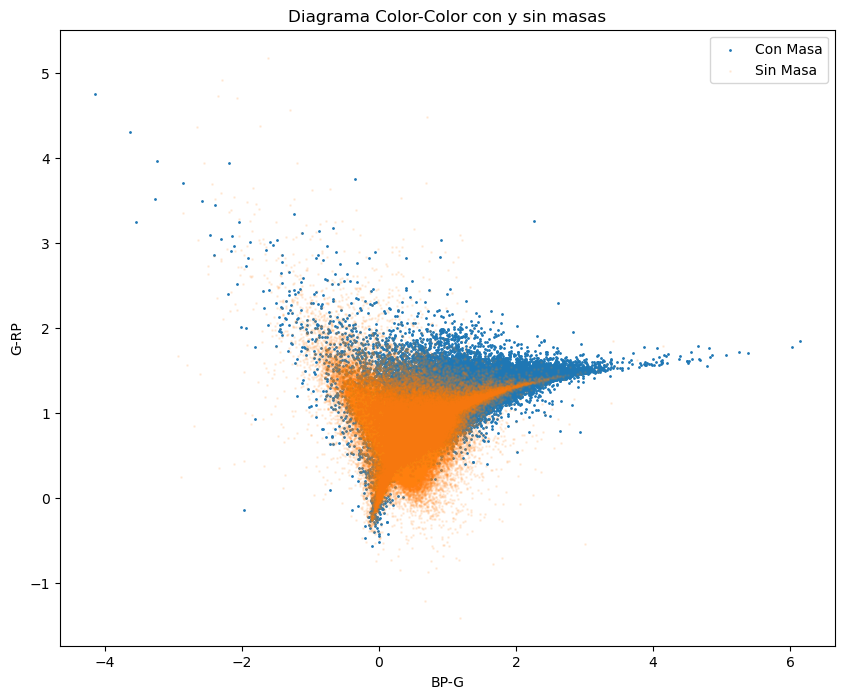

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(members_masses['BP-G'], members_masses['G-RP'], s=1, label='Con Masa')
ax.scatter(members_no_masses['BP-G'], members_no_masses['G-RP'], s=1, alpha=0.1, label='Sin Masa')
ax.set_xlabel('BP-G')
ax.set_ylabel('G-RP')
ax.set_title('Diagrama Color-Color con y sin masas')
ax.legend()
plt.show()

## Interpolación de masas faltantes

Se define la cuadrícula.

In [17]:
num_bins = 40

x_bins = np.linspace(
    members['BP-G'].min(), 
    members['BP-G'].max(), 
    num_bins + 1
)

y_bins = np.linspace(
    members['G-RP'].min(), 
    members['G-RP'].max(), 
    num_bins + 1
)

Se calcula la mediana por bin.

In [18]:
median_masses, x_edge, y_edge, _ = binned_statistic_2d(
    members_masses['BP-G'], 
    members_masses['G-RP'], 
    members_masses['Mass50'], 
    statistic='median', 
    bins=[x_bins, y_bins]
)

Se asignan masas a las estrellas sin masa. Se resta 1 porque `np.digitize` empieza a contar los bins desde 1.

In [19]:
idx_x = np.digitize(members_no_masses['BP-G'], x_bins) - 1
idx_y = np.digitize(members_no_masses['G-RP'], y_bins) - 1

Se limitan los índices al tamaño de la matriz, esto porque `np.digitize` puede dar índices fuera de rango si hay estrellas justo en el borde máximo.

In [20]:
idx_x = np.clip(idx_x, 0, len(x_edge) - 2)
idx_y = np.clip(idx_y, 0, len(y_edge) - 2)

Se asigna la masa extrayendo el valor de la matriz `median_masses`.

In [21]:
members_no_masses['estimated_mass'] = median_masses[idx_x, idx_y]

Se combina de nuevo a la tabla de miembros original.

In [22]:
members.loc[members_no_masses.index, 'Mass50'] = members_no_masses['estimated_mass']

### Gráfica de interpolación

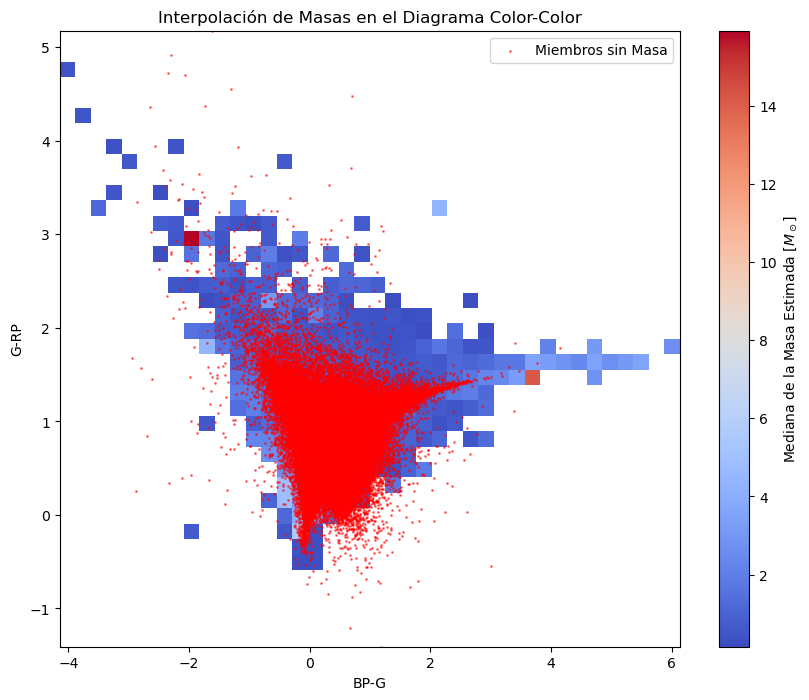

In [23]:
plt.figure(figsize=(10, 8))

plt.pcolormesh(x_edge, y_edge, median_masses.T, shading='auto', cmap='coolwarm')
cb = plt.colorbar(label='Mediana de la Masa Estimada [$M_\odot$]')

plt.scatter(members_no_masses['BP-G'], members_no_masses['G-RP'], s=1, alpha=0.5, color='red', label='Miembros sin Masa')

plt.xlabel('BP-G')
plt.ylabel('G-RP')
plt.title('Interpolación de Masas en el Diagrama Color-Color')
plt.legend()
plt.show()

Se guarda la tabla de miembros con las masas estimadas.

In [24]:
members.to_csv('../data/processed/members_with_estimated_masses.csv', index=False)